# EDA

## import libraries

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


## load data

In [3]:
DATA_PATH = Path("../data/raw/iot_sensor_data.csv")

df = pd.read_csv(DATA_PATH)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

,timestamp,device_id,location_id,temperature,humidity,co2,airspeed,light,x,y,production_day
0,2026-01-01 00:00:00,DEV_001,LOC_A,23.922834,65.226321,788.858799,0.369537,48.726615,0,0,1
1,2026-01-01 00:01:00,DEV_001,LOC_A,24.386213,62.853460,818.334831,0.367287,51.603935,0,0,1
2,2026-01-01 00:02:00,DEV_001,LOC_A,24.449512,62.602028,817.730583,0.342487,53.247124,0,0,1
3,2026-01-01 00:03:00,DEV_001,LOC_A,23.742381,62.852535,816.128724,0.384030,52.466760,0,0,1
4,2026-01-01 00:04:00,DEV_001,LOC_A,23.920363,63.315598,823.929473,0.337668,52.647733,0,0,1


In [4]:
print(f"Rows: {len(df):,}")
print(f"Devices: {df['device_id'].nunique()}")
print(f"Locations: {df['location_id'].nunique()}")
print(f"Time range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Rows: 432,000
Devices: 10
Locations: 5
Time range: 2026-01-01 00:00:00 -> 2026-01-30 23:59:00


## Sensors Distribution

In [5]:
sensor_columns = [
    "temperature",
    "humidity",
    "co2",
    "airspeed",
    "light",
]

df[sensor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,431500.0,24.171260,2.565840,18.665808,21.823593,24.175864,26.524171,42.849159
humidity,432000.0,64.804514,5.868199,51.783677,59.392892,64.783766,70.209510,129.937419
co2,432000.0,802.810142,136.364130,487.414473,684.298192,802.344369,920.892723,2328.916077
airspeed,432000.0,0.350140,0.058629,0.201931,0.295853,0.350156,0.404346,0.620076
light,432000.0,62.729992,15.716724,35.215285,49.869317,54.377031,78.106680,102.700001


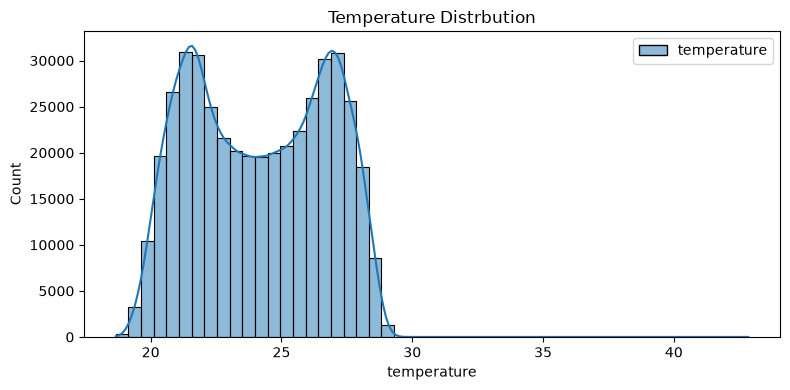

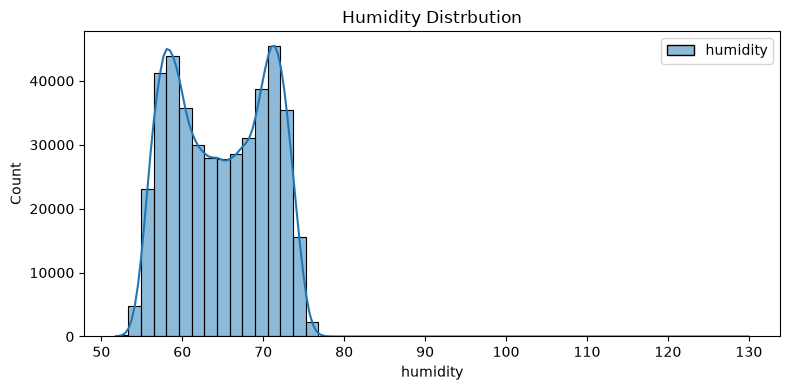

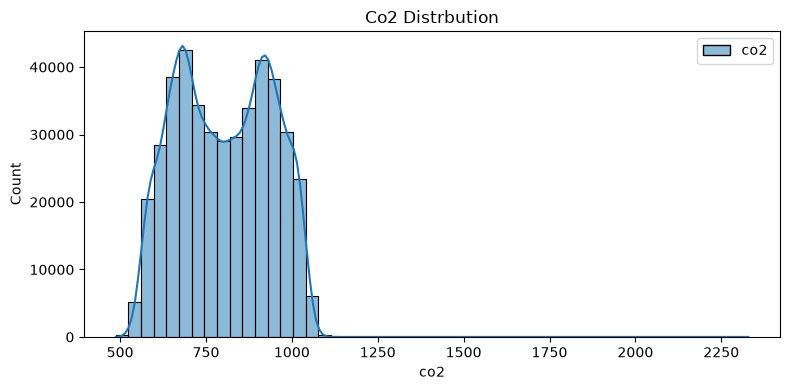

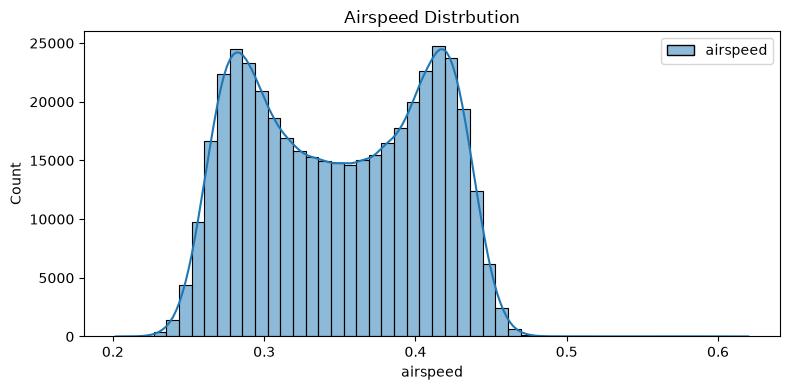

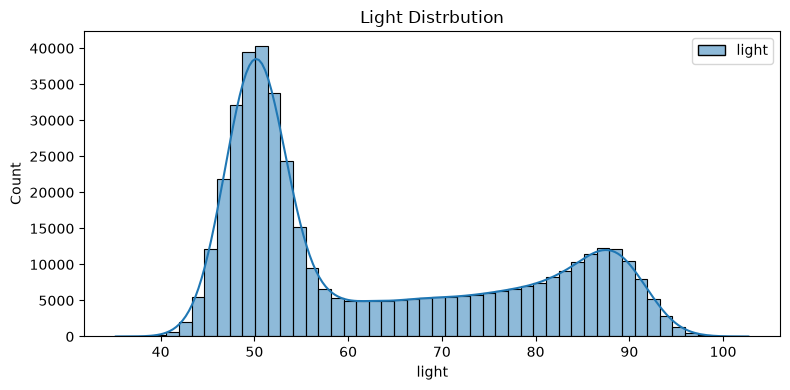

In [6]:
for sensor in sensor_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot([df[sensor]], bins=50, kde=True)
    plt.title(f"{sensor.title()} Distrbution")
    plt.xlabel(sensor)
    plt.tight_layout()
    plt.show()

## Time Series >> Temperature

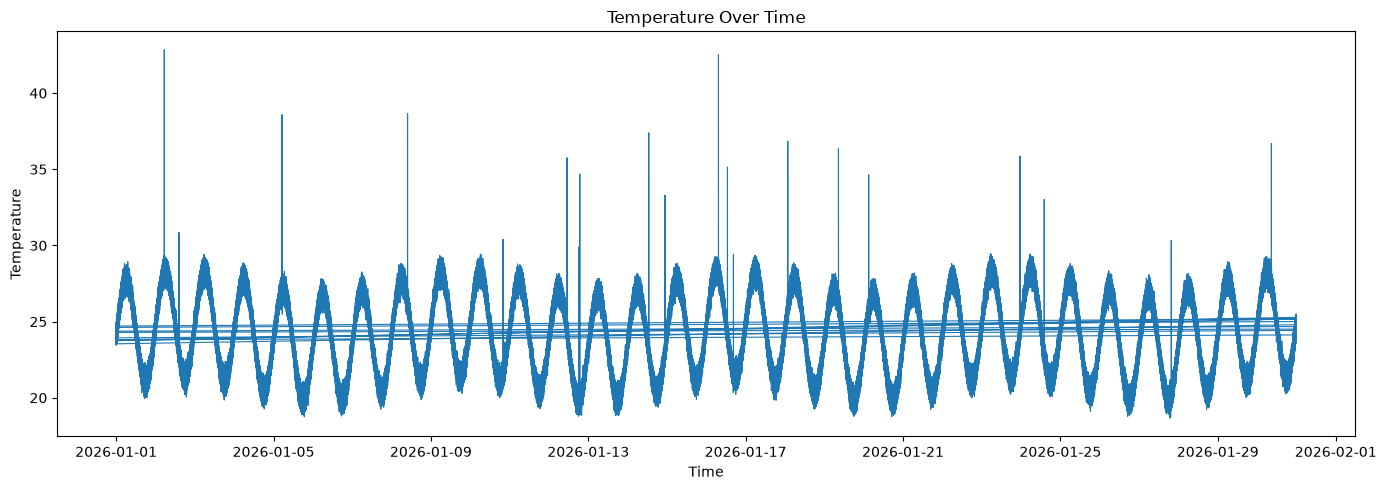

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["temperature"],
    linewidth=0.8
)

plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.tight_layout()
plt.show()

In [8]:
# resampling

hourly_temperature = (
    df.set_index("timestamp")
      ["temperature"]
      .resample("1h")
      .mean()
)

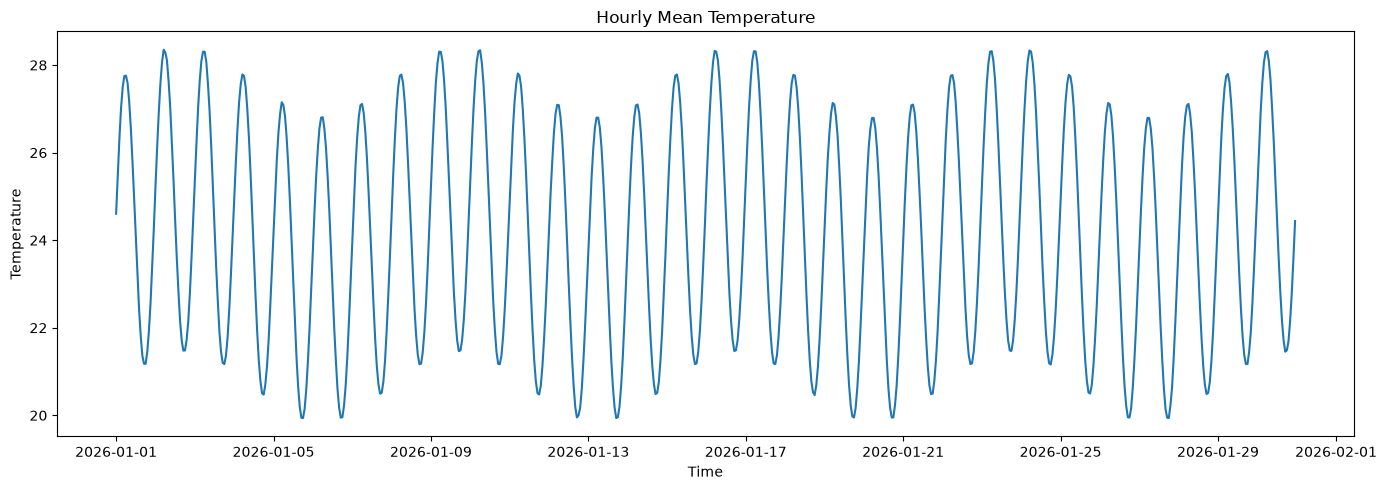

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(
    hourly_temperature.index,
    hourly_temperature.values
)

plt.title("Hourly Mean Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.tight_layout()
plt.show()

### Daily Routine?

In [10]:
df["hour"] = df["timestamp"].dt.hour

In [11]:
hourly_profile = (
    df.groupby("hour")[sensor_columns]
    .mean()
)

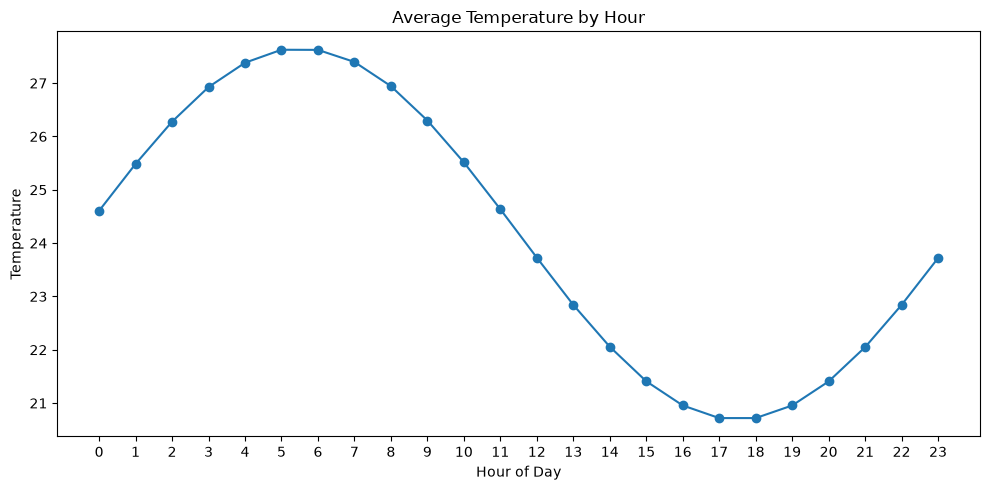

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile["temperature"],
    marker="o"
)

plt.title("Average Temperature by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

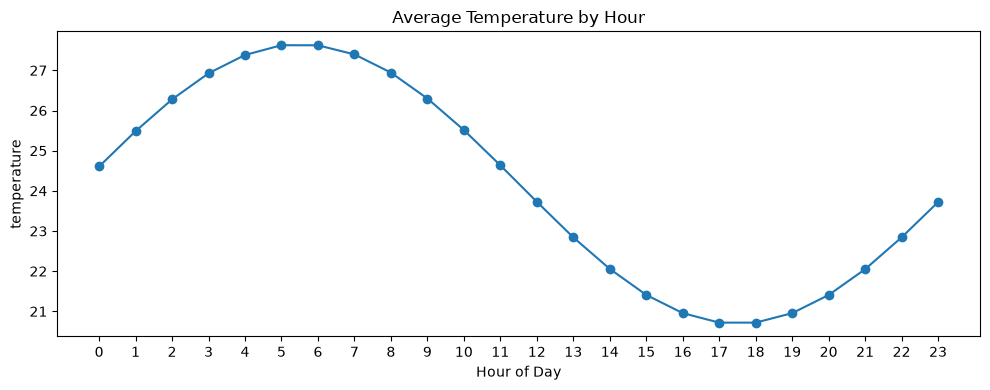

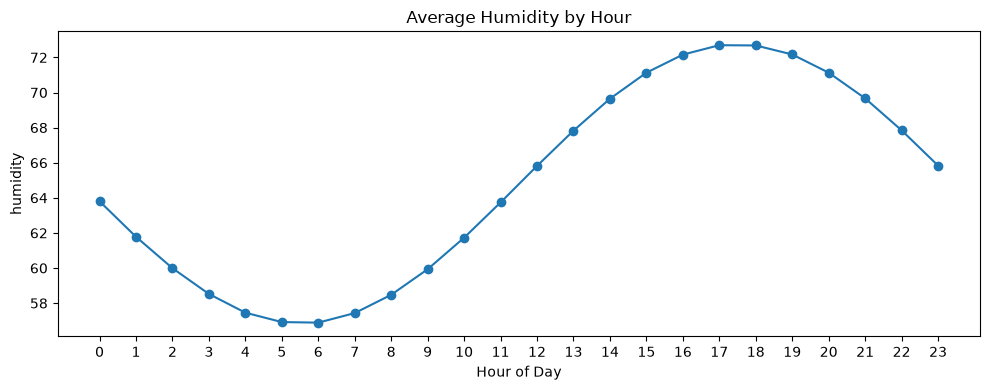

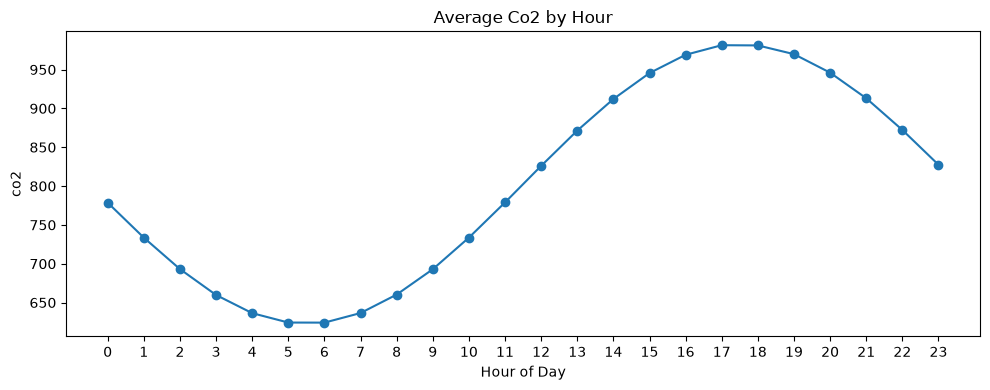

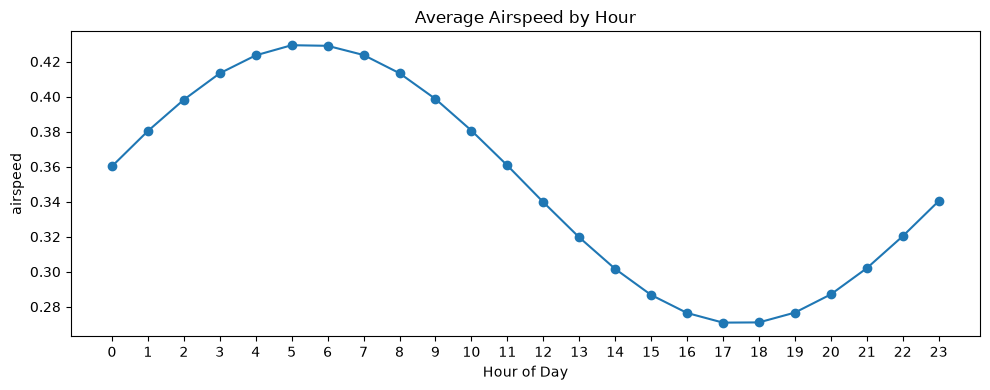

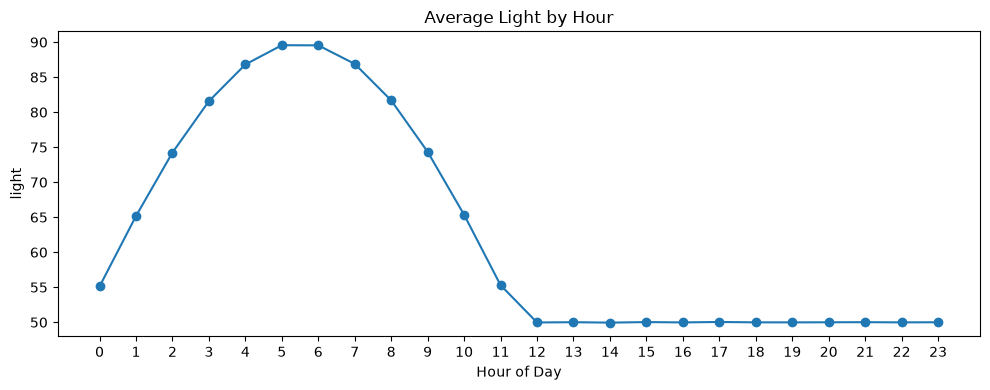

In [13]:
for sensor in sensor_columns:
    plt.figure(figsize=(10, 4))

    plt.plot(
        hourly_profile.index,
        hourly_profile[sensor],
        marker="o"
    )

    plt.title(f"Average {sensor.title()} by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel(sensor)
    plt.xticks(range(24))

    plt.tight_layout()
    plt.show()

## Device Comparison

In [14]:
device_temperature = (
    df.groupby("device_id")["temperature"]
      .mean()
      .sort_values()
)

device_temperature

device_id
DEV_003    23.642228
DEV_006    23.718467
DEV_007    23.829322
DEV_008    24.149023
DEV_001    24.220425
DEV_009    24.342960
DEV_010    24.359617
DEV_004    24.359945
DEV_002    24.530946
DEV_005    24.559618
Name: temperature, dtype: float64

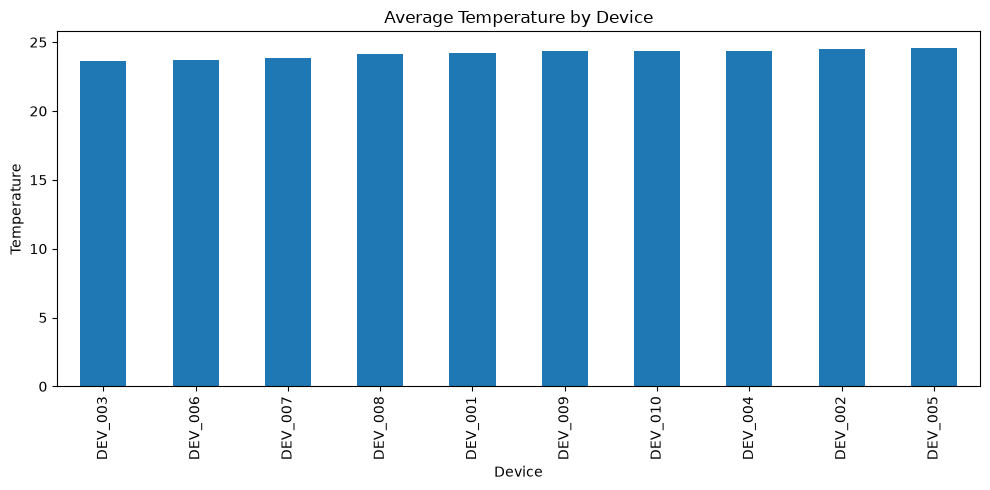

In [15]:
plt.figure(figsize=(10, 5))

device_temperature.plot(
    kind="bar"
)

plt.title("Average Temperature by Device")
plt.xlabel("Device")
plt.ylabel("Temperature")

plt.tight_layout()
plt.show()

## Location Comparison

In [17]:
location_temperature = (
    df.groupby("location_id")["temperature"]
      .mean()
      .sort_values()
)

location_temperature

location_id
LOC_D    23.989163
LOC_B    24.001103
LOC_C    24.139023
LOC_E    24.351288
LOC_A    24.375691
Name: temperature, dtype: float64

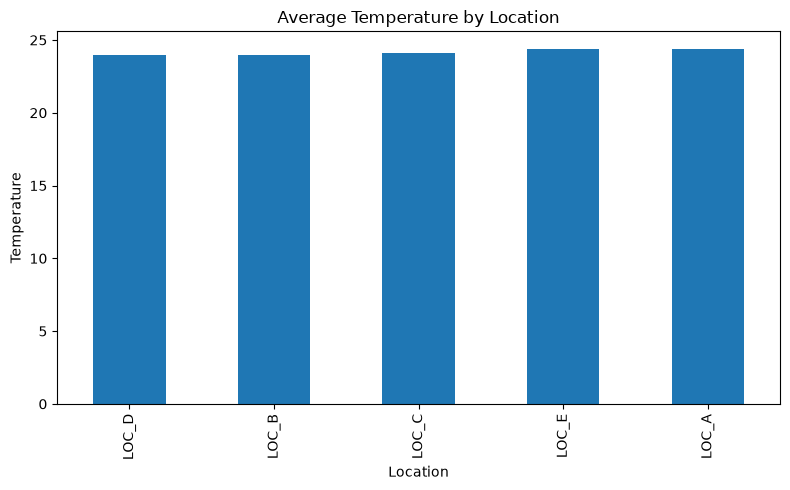

In [18]:
plt.figure(figsize=(8, 5))

location_temperature.plot(
    kind="bar"
)

plt.title("Average Temperature by Location")
plt.xlabel("Location")
plt.ylabel("Temperature")

plt.tight_layout()
plt.show()

## Sensor Correlation

In [19]:
correlation = df[sensor_columns].corr()

correlation

,temperature,humidity,co2,airspeed,light
temperature,1.000000,-0.972296,-0.832599,0.926790,0.865978
humidity,-0.972296,1.000000,0.844869,-0.926748,-0.865618
co2,-0.832599,0.844869,1.000000,-0.901639,-0.843180
airspeed,0.926790,-0.926748,-0.901639,1.000000,0.866380
light,0.865978,-0.865618,-0.843180,0.866380,1.000000


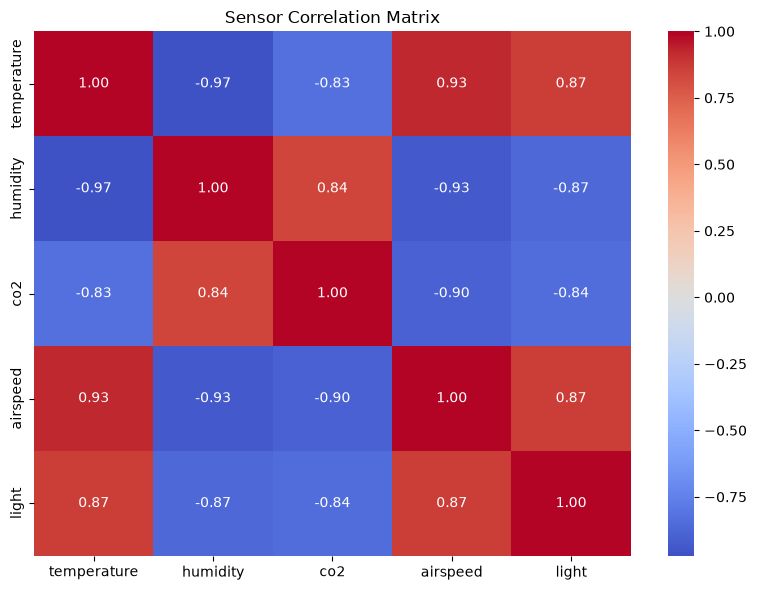

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Sensor Correlation Matrix")
plt.tight_layout()
plt.show()

### Temperature vs Humidity

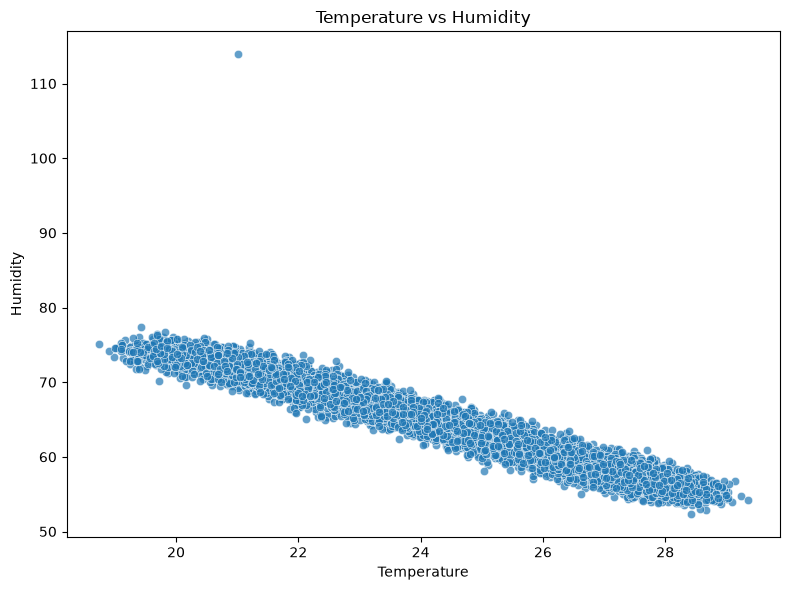

In [22]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="temperature",
    y="humidity",
    alpha=0.7
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature")
plt.ylabel("Humidity")

plt.tight_layout()
plt.show()

## Spatial Analysis

In [23]:
locations = (
    df[
        ["location_id", "x", "y"]
    ]
    .drop_duplicates()
)

locations

,location_id,x,y
0,LOC_A,0,0
86400,LOC_B,10,0
172800,LOC_C,0,10
259200,LOC_D,10,10
345600,LOC_E,5,5


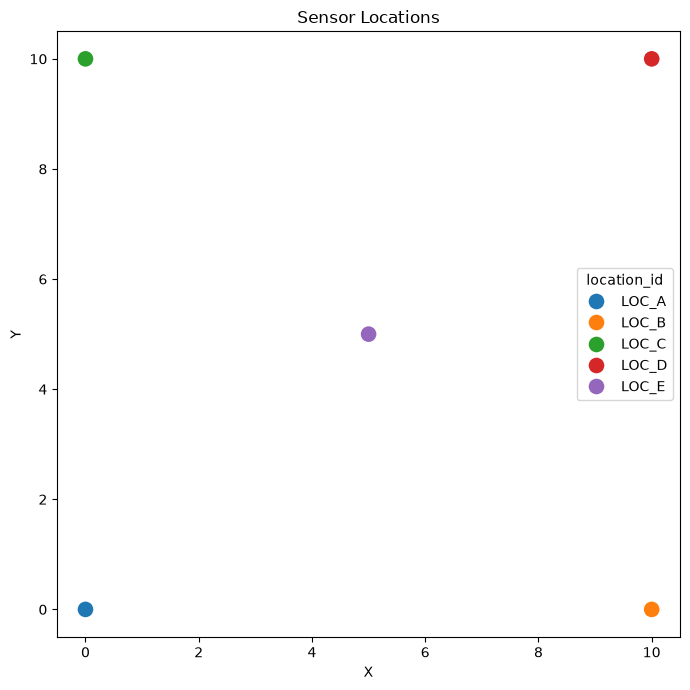

In [24]:
plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=locations,
    x="x",
    y="y",
    hue="location_id",
    s=150
)

plt.title("Sensor Locations")
plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()
plt.show()

In [25]:
location_sensor_means = (
    df.groupby("location_id")[sensor_columns]
      .mean()
)

location_sensor_means

,temperature,humidity,co2,airspeed,light
location_id,,,,,
LOC_A,24.375691,64.595896,802.697036,0.349996,62.728562
LOC_B,24.001103,64.975644,802.843931,0.349942,62.717653
LOC_C,24.139023,64.843801,802.936678,0.350078,62.737189
LOC_D,23.989163,64.983564,802.757340,0.350711,62.738056
LOC_E,24.351288,64.623664,802.815726,0.349971,62.728501
